## 1. Import Libraries

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

sns.set(style="whitegrid")


## 2. Load and Preprocess MNIST Dataset

In [31]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data, mnist.target.astype('int')
X = X / 255.0  # Normalize pixel values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


## 3. Train Classifier Models

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Support Vector Machine": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
}

results = {}
y_preds = {}

for name, model in models.items():
    print(f"Training {name}...")
    start = time.time()
    model.fit(X_train, y_train)
    end = time.time()

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    results[name] = {
        "accuracy": acc,
        "training_time": end - start,
        "classification_report": report
    }
    y_preds[name] = y_pred

Training Logistic Regression...
Training Support Vector Machine...
Training Decision Tree...
Training Random Forest...
Training XGBoost...


c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:01:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## 4. Model Evaluation

In [ ]:
for name in models.keys():
    print(f"\n{name} Classification Report:")
    print(classification_report(y_test, y_preds[name]))


Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      2071
           1       0.95      0.97      0.96      2363
           2       0.91      0.90      0.91      2097
           3       0.90      0.89      0.89      2142
           4       0.92      0.91      0.92      2047
           5       0.89      0.87      0.88      1894
           6       0.94      0.95      0.95      2063
           7       0.93      0.94      0.94      2188
           8       0.90      0.88      0.89      2048
           9       0.90      0.89      0.90      2087

    accuracy                           0.92     21000
   macro avg       0.92      0.92      0.92     21000
weighted avg       0.92      0.92      0.92     21000


Support Vector Machine Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      2071
           1       0.98      0.99      0.

## 5. Compare Accuracy of All Models

In [ ]:
summary_df = pd.DataFrame({
    "Model": list(results.keys()),
    "Accuracy": [results[m]["accuracy"] for m in results],
    "Training Time (s)": [results[m]["training_time"] for m in results]
})

summary_df.sort_values("Accuracy", ascending=False, inplace=True)
summary_df.reset_index(drop=True, inplace=True)
summary_df


,Model,Accuracy,Training Time (s)
0,Support Vector Machine,0.976762,114.866624
1,XGBoost,0.974905,153.387771
2,Random Forest,0.965952,25.841445
3,Logistic Regression,0.919952,24.677624
4,Decision Tree,0.865381,12.743317


## 6. Accuracy Comparison Bar Plot

C:\Users\admin\AppData\Local\Temp\ipykernel_17700\291147944.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=summary_df, palette='viridis')


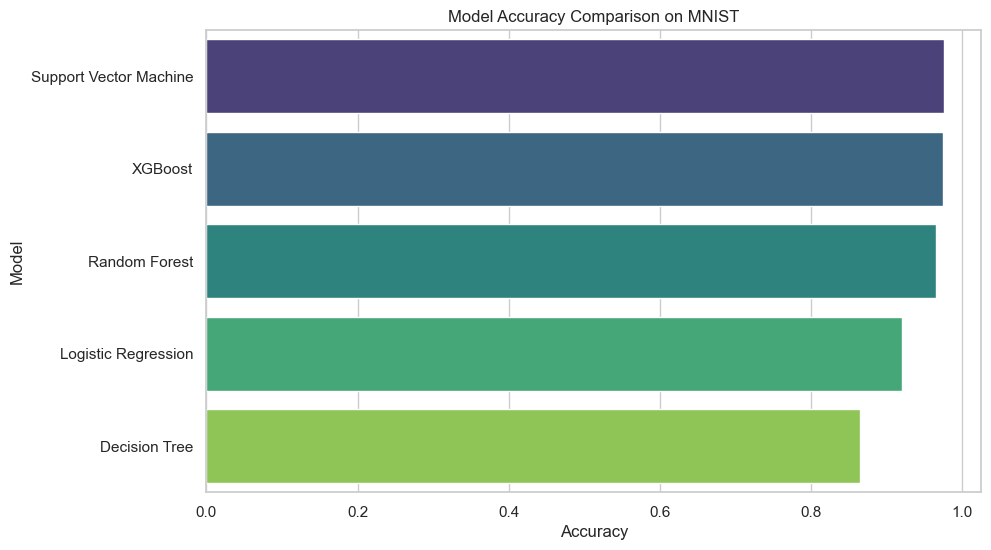

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Model', data=summary_df, palette='viridis')
plt.title('Model Accuracy Comparison on MNIST')
plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.show()

## 7. Error Analysis: Misclassified Images

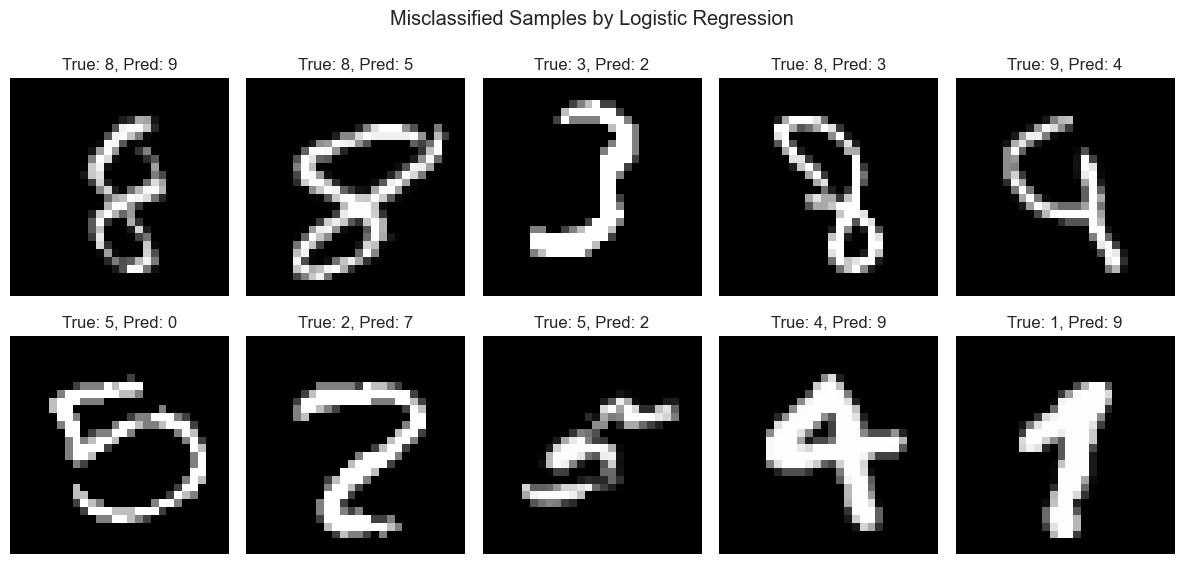

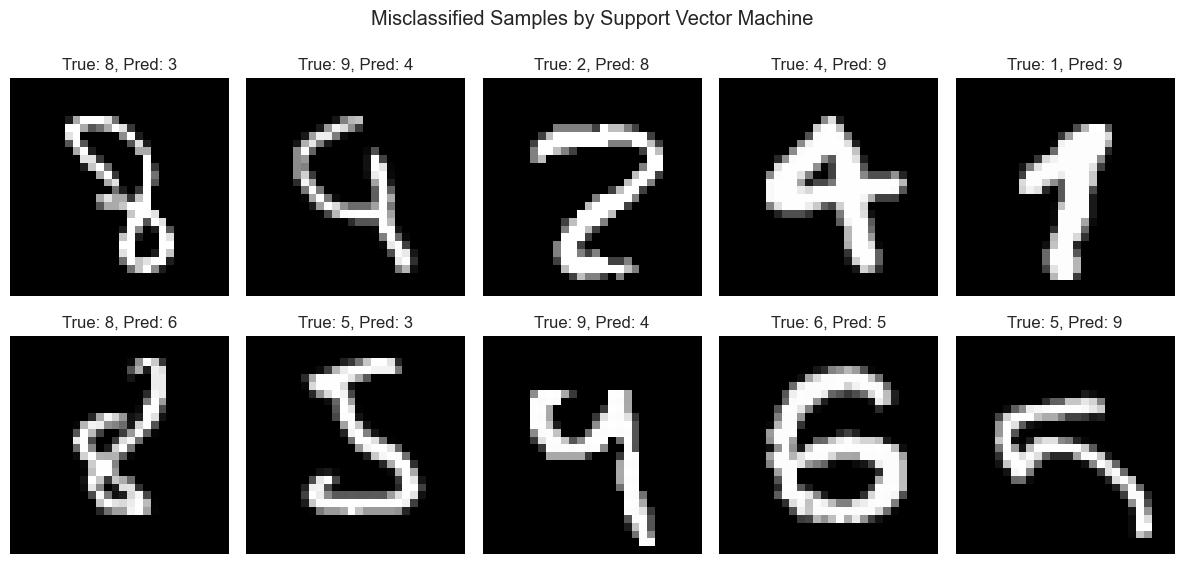

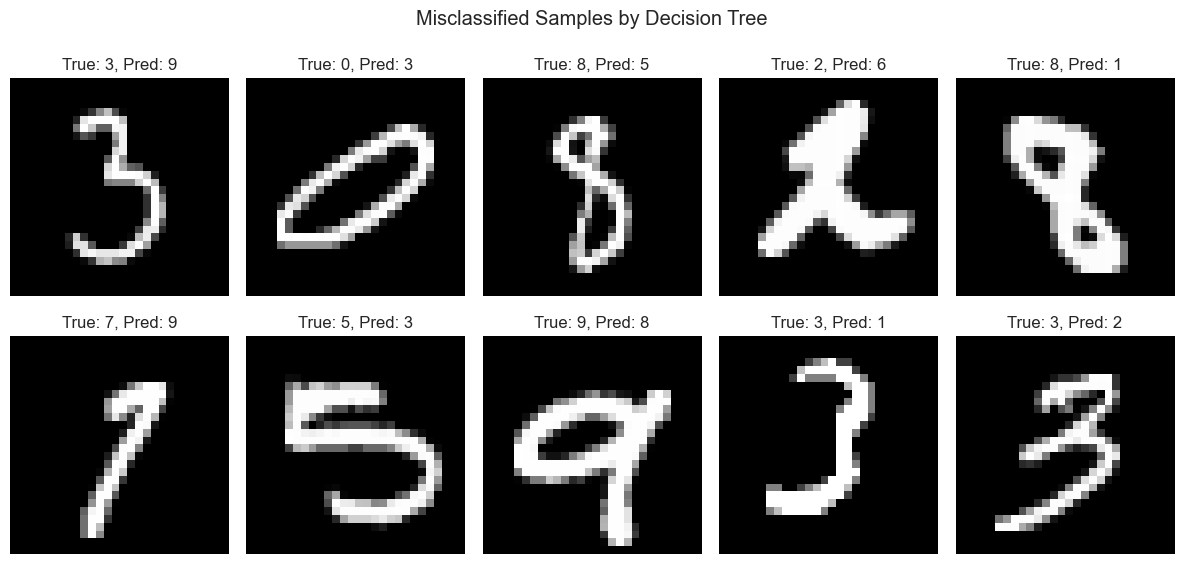

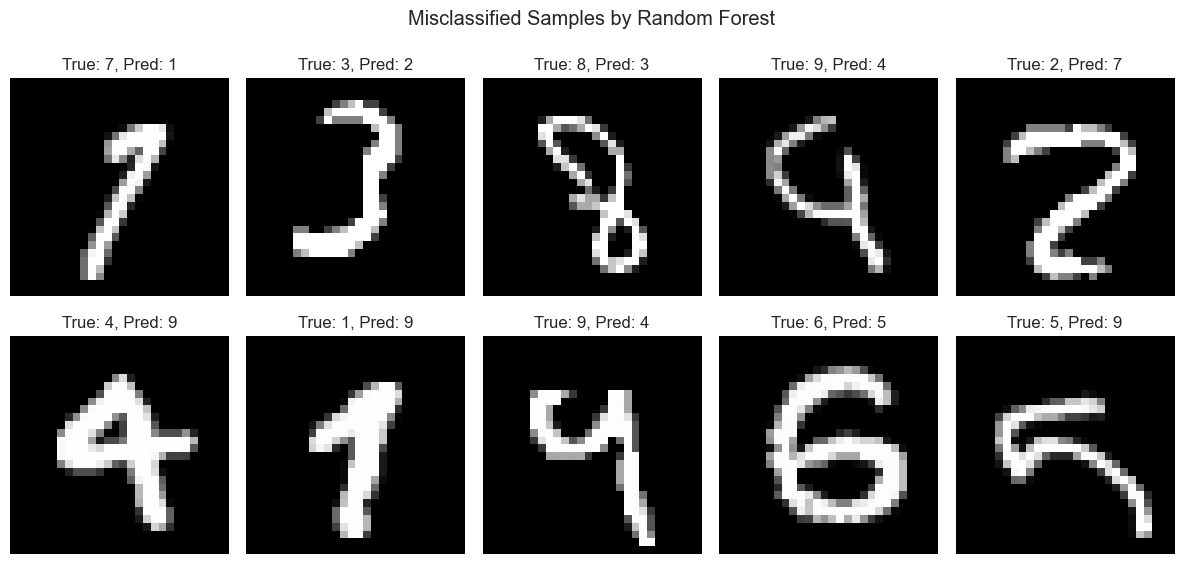

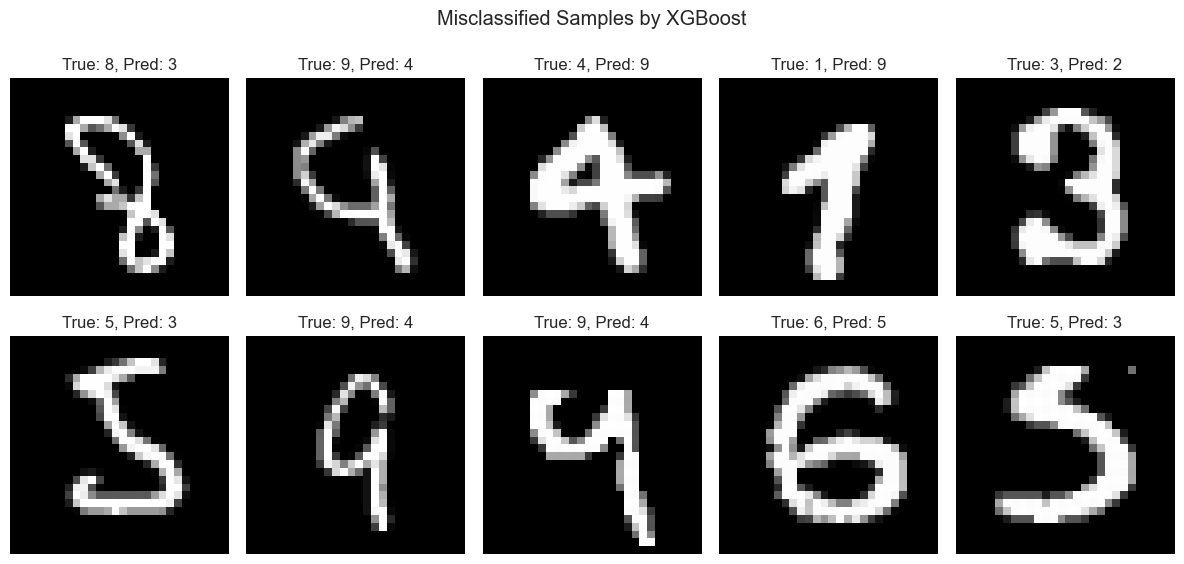

In [ ]:
def plot_misclassified(model_name, num_images=10):
    pred = y_preds[model_name]
    misclassified = np.where(pred != y_test)[0]

    plt.figure(figsize=(12, 6))
    for i, index in enumerate(misclassified[:num_images]):
        plt.subplot(2, num_images//2, i+1)
        plt.imshow(X_test[index].reshape(28, 28), cmap='gray')
        plt.title(f"True: {y_test[index]}, Pred: {pred[index]}")
        plt.axis('off')
    plt.suptitle(f"Misclassified Samples by {model_name}")
    plt.tight_layout()
    plt.show()

for model_name in models.keys():
    plot_misclassified(model_name, 10)

